In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s5e12/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e12/train.csv
/kaggle/input/competitions/playground-series-s5e12/test.csv


## 01. Dataset Loading & Target Intelligence

Before building any machine-learning model, we need to understand the structure of the prediction problem.

This competition contains **700,000 training records and 300,000 test records**, making it large enough that inefficient exploratory operations can become unnecessarily expensive.

In this section we will:

- Load the training and test data efficiently
- Separate the target from the predictors
- Identify numerical and categorical features
- Examine the target distribution
- Check the number of unique values in every feature
- Inspect categorical levels
- Compare train and test feature distributions at a high level

>  **Speed-first principle:**  
> We will load the data once, reuse the DataFrames throughout the notebook, and avoid repeatedly reading the 80+ MB training file from disk.

### Main question

**What exactly are we trying to predict, and how balanced is the diabetes target?**

Understanding this now will determine our validation strategy, evaluation metric handling, model selection, and feature engineering later.

 LOADING PLAYGROUND SERIES S5E12

 Data loaded successfully!

Train shape : 700,000 rows × 26 columns
Test shape  : 300,000 rows × 25 columns
Submission  : 300,000 rows × 2 columns

 TARGET INFORMATION

Target column : diagnosed_diabetes
Target dtype  : float64
Target rows   : 700,000
Unique values : [np.float64(0.0), np.float64(1.0)]

 Target Distribution:


,Count,Percentage
diagnosed_diabetes,,
0.0,263693,37.67
1.0,436307,62.33



 FEATURE TYPES

Numerical features   : 19
Categorical features : 6

 Numerical:
['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']

 Categorical:
['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']

 FEATURE CARDINALITY


,dtype,unique_values,missing_values,unique_%
id,int64,700000,0,100.000
physical_activity_minutes_per_week,int64,565,0,0.081
bmi,float64,231,0,0.033
triglycerides,int64,228,0,0.033
cholesterol_total,int64,154,0,0.022
screen_time_hours_per_day,float64,151,0,0.022
ldl_cholesterol,int64,151,0,0.022
diet_score,float64,99,0,0.014
systolic_bp,int64,71,0,0.010
age,int64,71,0,0.010



 CATEGORICAL LEVELS

 gender
Unique values: 3
gender
Female    363237
Male      333085
Other       3678
Name: count, dtype: int64

 ethnicity
Unique values: 5
ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64

 education_level
Unique values: 4
education_level
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: count, dtype: int64

 income_level
Unique values: 5
income_level
Middle          290557
Lower-Middle    178570
Upper-Middle    127836
Low              85803
High             17234
Name: count, dtype: int64

 smoking_status
Unique values: 3
smoking_status
Never      494448
Current    103363
Former     102189
Name: count, dtype: int64

 employment_status
Unique values: 4
employment_status
Employed      516170
Retired       115735
Unemployed     49787
Student        18308
Name: count, dtype: int64


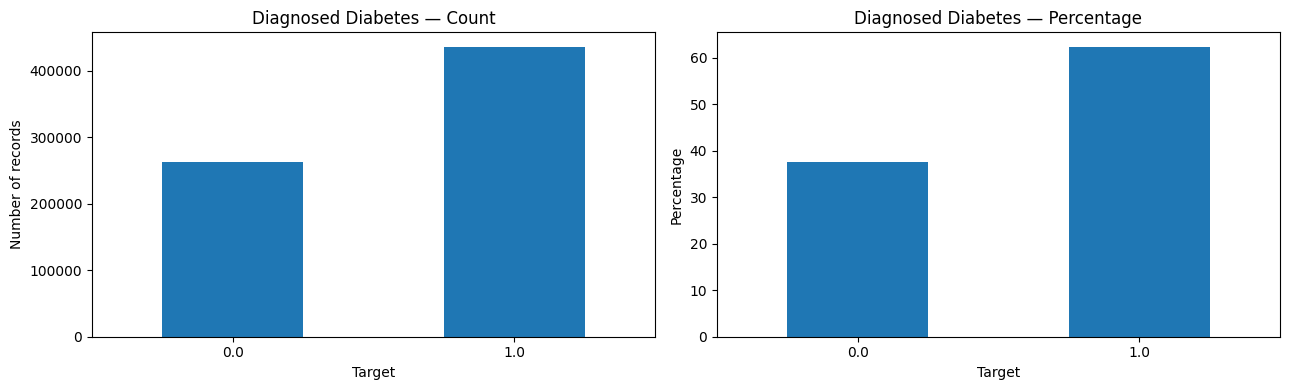


 INITIAL DATA PROFILE COMPLETE

Train records       : 700,000
Test records        : 300,000
Features            : 25
Numerical features  : 19
Categorical features: 6
Missing train cells : 0
Missing test cells  : 0
Target classes      : 2



In [4]:
# ============================================================
#  01 — LOAD DATA & TARGET INTELLIGENCE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

DATA_DIR = Path("/kaggle/input/competitions/playground-series-s5e12")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

TARGET = "diagnosed_diabetes"

# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

print("=" * 75)
print(" LOADING PLAYGROUND SERIES S5E12")
print("=" * 75)

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_PATH)

print("\n Data loaded successfully!")

print(f"\nTrain shape : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Test shape  : {test.shape[0]:,} rows × {test.shape[1]} columns")
print(f"Submission  : {sample_submission.shape[0]:,} rows × {sample_submission.shape[1]} columns")

# ------------------------------------------------------------
# Separate target
# ------------------------------------------------------------

X = train.drop(columns=[TARGET])
y = train[TARGET]

print("\n" + "=" * 75)
print(" TARGET INFORMATION")
print("=" * 75)

print(f"\nTarget column : {TARGET}")
print(f"Target dtype  : {y.dtype}")
print(f"Target rows   : {len(y):,}")
print(f"Unique values : {sorted(y.unique())}")

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

target_counts = y.value_counts().sort_index()
target_percent = y.value_counts(normalize=True).sort_index().mul(100)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(3)
})

print("\n Target Distribution:")
display(target_summary)

# ------------------------------------------------------------
# Feature types
# ------------------------------------------------------------

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\n" + "=" * 75)
print(" FEATURE TYPES")
print("=" * 75)

print(f"\nNumerical features   : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")

print("\n Numerical:")
print(numeric_features)

print("\n Categorical:")
print(categorical_features)

# ------------------------------------------------------------
# Unique-value analysis
# ------------------------------------------------------------

unique_summary = pd.DataFrame({
    "dtype": train.dtypes,
    "unique_values": train.nunique(),
    "missing_values": train.isna().sum()
})

unique_summary["unique_%"] = (
    unique_summary["unique_values"] / len(train) * 100
).round(3)

print("\n" + "=" * 75)
print(" FEATURE CARDINALITY")
print("=" * 75)

display(
    unique_summary.sort_values(
        "unique_values",
        ascending=False
    )
)

# ------------------------------------------------------------
# Categorical levels
# ------------------------------------------------------------

print("\n" + "=" * 75)
print(" CATEGORICAL LEVELS")
print("=" * 75)

for col in categorical_features:
    print(f"\n {col}")
    print(f"Unique values: {train[col].nunique()}")
    print(train[col].value_counts(dropna=False).head(20))

# ------------------------------------------------------------
# Target visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count plot
target_counts.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Diagnosed Diabetes — Count")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Number of records")
axes[0].tick_params(axis="x", rotation=0)

# Percentage plot
target_percent.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Diagnosed Diabetes — Percentage")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Percentage")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final quick summary
# ------------------------------------------------------------

print("\n" + "=" * 75)
print(" INITIAL DATA PROFILE COMPLETE")
print("=" * 75)

print(f"""
Train records       : {len(train):,}
Test records        : {len(test):,}
Features            : {X.shape[1]:,}
Numerical features  : {len(numeric_features)}
Categorical features: {len(categorical_features)}
Missing train cells : {train.isna().sum().sum():,}
Missing test cells  : {test.isna().sum().sum():,}
Target classes      : {y.nunique()}
""")

## 02. Target Intelligence & ID Signal Investigation

We now move beyond basic dataset inspection.

The most important questions are:

### Target
- Is `diagnosed_diabetes` uniformly distributed across the dataset?
- Does the diabetes rate change across different portions of the training data?

### ID
Normally, an identifier such as `id` would be removed before machine learning.

However, this competition is unusual.

Community analysis of Playground Series S5E12 found evidence that the target rate changes across ID order, suggesting that the synthetic data generation process may contain latent drift or batch structure.

Therefore:

> **We will test the ID signal empirically instead of assuming it is useless.**

We will investigate:

- target rate by ID quantile
- target rate by ID bins
- rolling target rate
- target relationship with `id`
- whether the ID pattern is smooth or noisy

This analysis is especially important because the test set begins immediately after the training IDs, making train/test ordering potentially meaningful.

### Important

We are **not deciding yet** whether `id` belongs in the final model.

We are only measuring whether it contains reproducible signal.

 TARGET RATE ACROSS ID QUANTILES


,id_quantile,min_id,max_id,rows,diabetes_rate,diabetes_rate_pct
0,0,0,34999,35000,0.620086,62.009
1,1,35000,69999,35000,0.621143,62.114
2,2,70000,104999,35000,0.624000,62.400
3,3,105000,139999,35000,0.622971,62.297
4,4,140000,174999,35000,0.624886,62.489
5,5,175000,209999,35000,0.625514,62.551
6,6,210000,244999,35000,0.622343,62.234
7,7,245000,279999,35000,0.621543,62.154
8,8,280000,314999,35000,0.622914,62.291
9,9,315000,349999,35000,0.626571,62.657


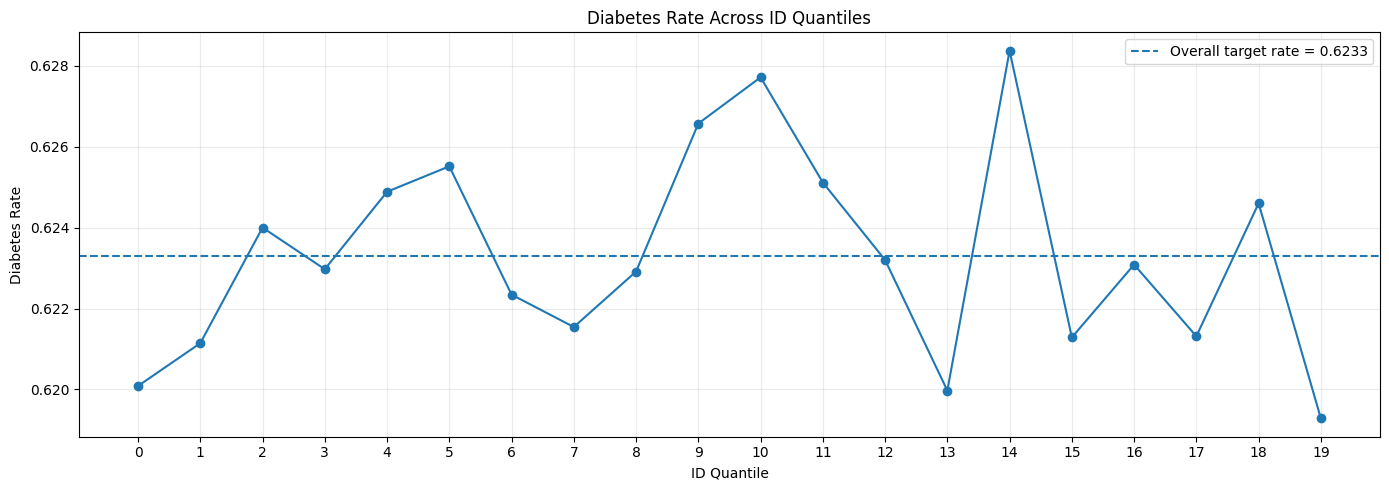


 Target-rate range across ID quantiles:
Minimum : 0.61929
Maximum : 0.62837
Range   : 0.00909


In [5]:
# ============================================================
#  TARGET RATE ACROSS ID ORDER
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Work on a lightweight view
id_target = train[["id", TARGET]].copy()

# ------------------------------------------------------------
# Create ID quantile bins
# ------------------------------------------------------------

id_target["id_quantile"] = pd.qcut(
    id_target["id"],
    q=20,
    labels=False
)

id_bins = (
    id_target
    .groupby("id_quantile", observed=True)
    .agg(
        min_id=("id", "min"),
        max_id=("id", "max"),
        rows=(TARGET, "size"),
        diabetes_rate=(TARGET, "mean")
    )
    .reset_index()
)

id_bins["diabetes_rate_pct"] = (
    id_bins["diabetes_rate"] * 100
).round(3)

print("=" * 75)
print(" TARGET RATE ACROSS ID QUANTILES")
print("=" * 75)

display(id_bins)

# ------------------------------------------------------------
# Plot target rate across ID quantiles
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    id_bins["id_quantile"],
    id_bins["diabetes_rate"],
    marker="o"
)

plt.axhline(
    y=y.mean(),
    linestyle="--",
    label=f"Overall target rate = {y.mean():.4f}"
)

plt.title("Diabetes Rate Across ID Quantiles")
plt.xlabel("ID Quantile")
plt.ylabel("Diabetes Rate")
plt.xticks(range(20))
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Range of target rates
# ------------------------------------------------------------

print("\n Target-rate range across ID quantiles:")
print(
    f"Minimum : {id_bins['diabetes_rate'].min():.5f}"
)
print(
    f"Maximum : {id_bins['diabetes_rate'].max():.5f}"
)
print(
    f"Range   : "
    f"{id_bins['diabetes_rate'].max() - id_bins['diabetes_rate'].min():.5f}"
)

### ID Drift: Smooth Signal or Random Noise?

The previous chart gives us the first indication of whether target probability changes with row order.

Now we increase the resolution.

Instead of only 20 large bins, we will calculate the target rate across **100 equally sized ID groups**.

This helps reveal:

- gradual trends
- periodic patterns
- sudden transitions
- localized target shifts
- synthetic-generation artifacts

We will also calculate a rolling target mean.

### Why rolling mean?

Individual observations are binary (`0` or `1`), so the raw target sequence is extremely noisy.

A rolling mean converts:

```text
0 1 1 0 1 1 1 0 1 ...

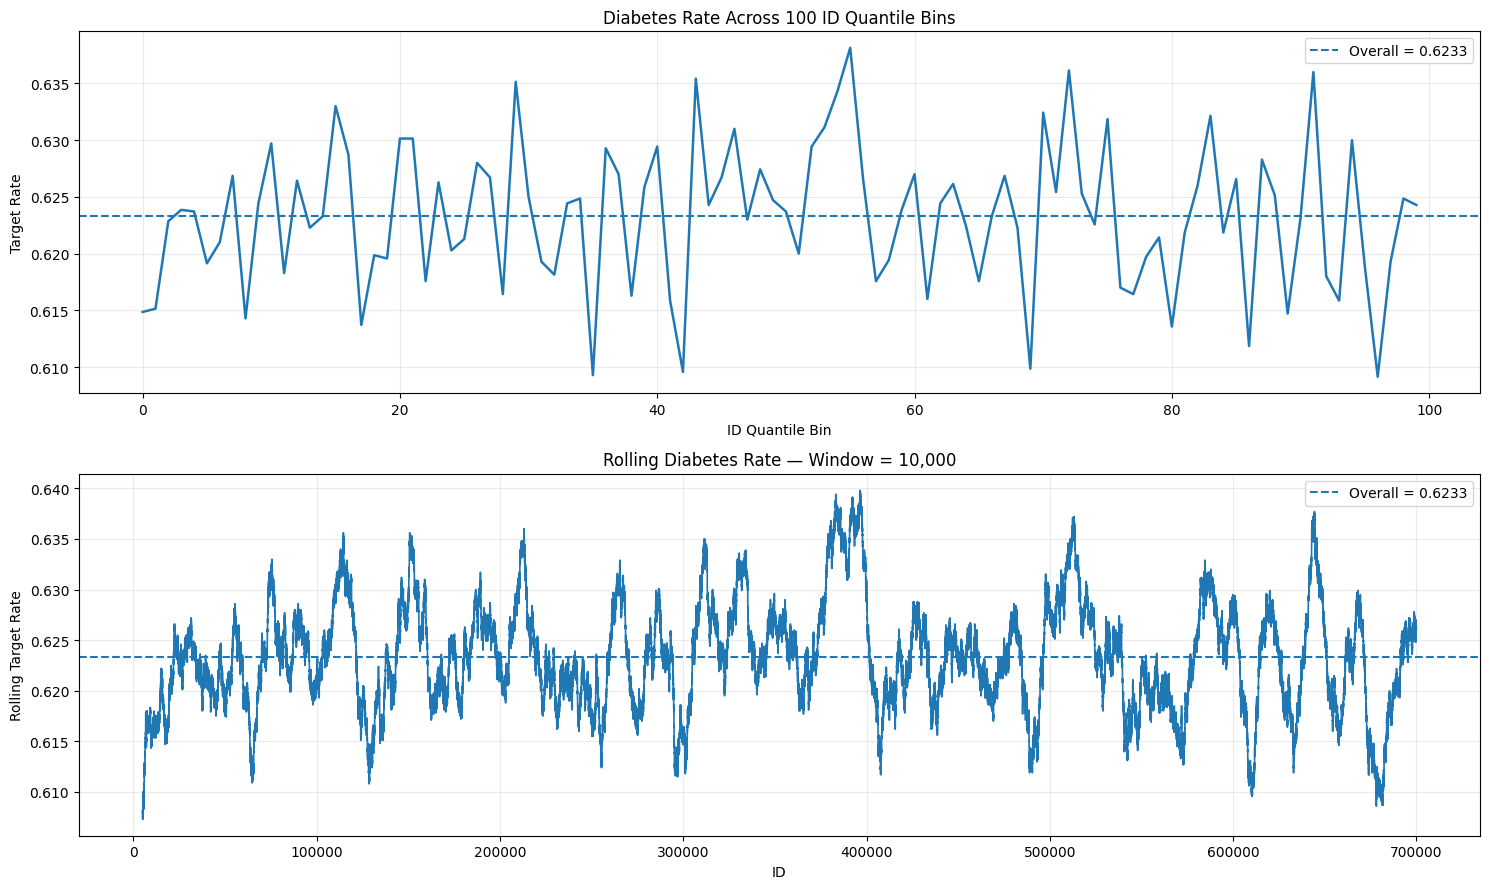


 Lowest target-rate ID regions:


,id_bin_100,mean,count
96,96,0.609143,7000
35,35,0.609286,7000
42,42,0.609571,7000
69,69,0.609857,7000
86,86,0.611857,7000



 Highest target-rate ID regions:


,id_bin_100,mean,count
55,55,0.638143,7000
72,72,0.636143,7000
91,91,0.636000,7000
43,43,0.635429,7000
29,29,0.635143,7000


In [6]:

# ============================================================
#  HIGH-RESOLUTION ID DRIFT ANALYSIS
# ============================================================

# Sort by ID
id_sorted = train[["id", TARGET]].sort_values("id").copy()

# ------------------------------------------------------------
# 100 ID bins
# ------------------------------------------------------------

id_sorted["id_bin_100"] = pd.qcut(
    id_sorted["id"],
    q=100,
    labels=False
)

id_100 = (
    id_sorted
    .groupby("id_bin_100", observed=True)[TARGET]
    .agg(["mean", "count"])
    .reset_index()
)

# ------------------------------------------------------------
# Rolling target mean
# ------------------------------------------------------------

ROLLING_WINDOW = 10_000

id_sorted["rolling_target"] = (
    id_sorted[TARGET]
    .rolling(
        window=ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW // 2
    )
    .mean()
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 9)
)

# 100-bin target rate
axes[0].plot(
    id_100["id_bin_100"],
    id_100["mean"],
    linewidth=1.8
)

axes[0].axhline(
    y=y.mean(),
    linestyle="--",
    label=f"Overall = {y.mean():.4f}"
)

axes[0].set_title(
    "Diabetes Rate Across 100 ID Quantile Bins"
)

axes[0].set_xlabel("ID Quantile Bin")
axes[0].set_ylabel("Target Rate")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Rolling mean
axes[1].plot(
    id_sorted["id"],
    id_sorted["rolling_target"],
    linewidth=1.2
)

axes[1].axhline(
    y=y.mean(),
    linestyle="--",
    label=f"Overall = {y.mean():.4f}"
)

axes[1].set_title(
    f"Rolling Diabetes Rate — Window = {ROLLING_WINDOW:,}"
)

axes[1].set_xlabel("ID")
axes[1].set_ylabel("Rolling Target Rate")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print extreme regions
# ------------------------------------------------------------

lowest = id_100.nsmallest(5, "mean")
highest = id_100.nlargest(5, "mean")

print("\n Lowest target-rate ID regions:")
display(lowest)

print("\n Highest target-rate ID regions:")
display(highest)

## 03. Train vs Test Distribution Shift

The next question is extremely important.

The training IDs are:

```text
0 → 699,999

 ID RANGE
Train ID: 0 → 699,999
Test ID : 700,000 → 999,999

 NUMERICAL TRAIN / TEST SHIFT


,feature,train_mean,test_mean,mean_diff_%,train_std,test_std,train_median,test_median,abs_mean_diff_%
2,physical_activity_minutes_per_week,80.2308,92.3491,15.1043,51.1951,62.1874,71.00,77.00,15.1043
17,cardiovascular_history,0.0303,0.0331,9.1864,0.1715,0.1789,0.00,0.00,9.1864
15,family_history_diabetes,0.1494,0.1529,2.3551,0.3565,0.3599,0.00,0.00,2.3551
16,hypertension_history,0.1820,0.1844,1.3297,0.3858,0.3878,0.00,0.00,1.3297
1,alcohol_consumption_per_week,2.0724,2.0897,0.8339,1.0482,1.0662,2.00,2.00,0.8339
13,ldl_cholesterol,102.9059,103.4161,0.4958,19.0224,20.5719,103.00,103.00,0.4958
14,triglycerides,123.0818,123.5385,0.3710,24.7394,28.9654,123.00,123.00,0.3710
3,diet_score,5.9637,5.9458,-0.2994,1.4633,1.4811,6.00,6.00,0.2994
11,cholesterol_total,186.8188,187.3086,0.2622,16.7308,18.4131,187.00,187.00,0.2622
10,heart_rate,70.1677,70.0484,-0.1702,6.9387,7.0905,70.00,70.00,0.1702


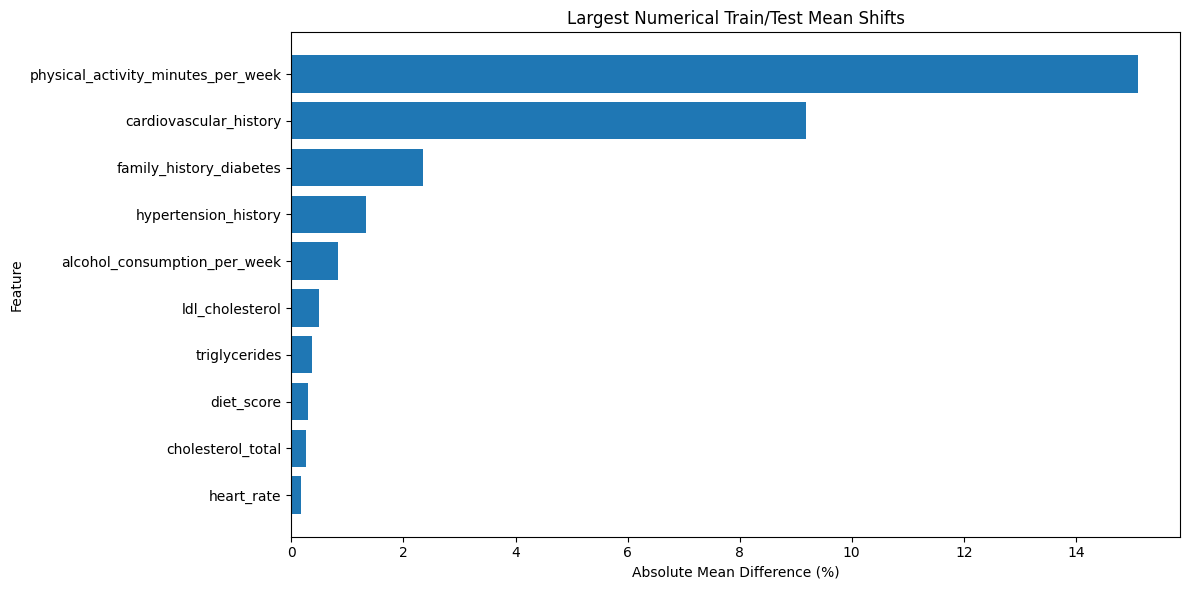

In [7]:

# ============================================================
#  TRAIN vs TEST DISTRIBUTION ANALYSIS
# ============================================================

# ------------------------------------------------------------
# Basic ID ranges
# ------------------------------------------------------------

print("=" * 75)
print(" ID RANGE")
print("=" * 75)

print(
    f"Train ID: {train['id'].min():,} → {train['id'].max():,}"
)

print(
    f"Test ID : {test['id'].min():,} → {test['id'].max():,}"
)

# ------------------------------------------------------------
# Numerical distribution comparison
# ------------------------------------------------------------

numeric_no_id = [
    col for col in numeric_features
    if col != "id"
]

distribution_rows = []

for col in numeric_no_id:

    train_mean = train[col].mean()
    test_mean = test[col].mean()

    train_std = train[col].std()
    test_std = test[col].std()

    train_median = train[col].median()
    test_median = test[col].median()

    mean_diff_pct = (
        (test_mean - train_mean)
        / (abs(train_mean) + 1e-9)
        * 100
    )

    distribution_rows.append({
        "feature": col,
        "train_mean": train_mean,
        "test_mean": test_mean,
        "mean_diff_%": mean_diff_pct,
        "train_std": train_std,
        "test_std": test_std,
        "train_median": train_median,
        "test_median": test_median
    })

distribution_df = pd.DataFrame(
    distribution_rows
)

distribution_df["abs_mean_diff_%"] = (
    distribution_df["mean_diff_%"]
    .abs()
)

distribution_df = distribution_df.sort_values(
    "abs_mean_diff_%",
    ascending=False
)

print("\n" + "=" * 75)
print(" NUMERICAL TRAIN / TEST SHIFT")
print("=" * 75)

display(
    distribution_df.round(4)
)

# ------------------------------------------------------------
# Visualize largest mean shifts
# ------------------------------------------------------------

top_shift = distribution_df.head(10).copy()

plt.figure(figsize=(12, 6))

plt.barh(
    top_shift["feature"],
    top_shift["abs_mean_diff_%"]
)

plt.xlabel("Absolute Mean Difference (%)")
plt.ylabel("Feature")
plt.title("Largest Numerical Train/Test Mean Shifts")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Categorical Distribution Shift

Numerical features are only part of the story.

The six categorical variables can also have different distributions between train and test.

For example:

```text
Train:
White       55%
Hispanic    19%
Black       15%
...

Test:
White       54%
Hispanic    20%
Black       15%
...

 CATEGORICAL TRAIN / TEST SHIFT


,feature,category,train_%,test_%,absolute_shift_%
8,education_level,Graduate,37.324,35.147,2.177
9,education_level,Highschool,49.164,51.118,1.955
20,employment_status,Employed,73.739,72.664,1.074
7,ethnicity,White,55.165,56.125,0.960
5,ethnicity,Hispanic,18.569,17.845,0.724
21,employment_status,Retired,16.534,17.069,0.535
0,gender,Female,51.891,51.366,0.525
1,gender,Male,47.584,48.034,0.450
22,employment_status,Student,2.615,2.973,0.358
3,ethnicity,Asian,8.589,8.359,0.230


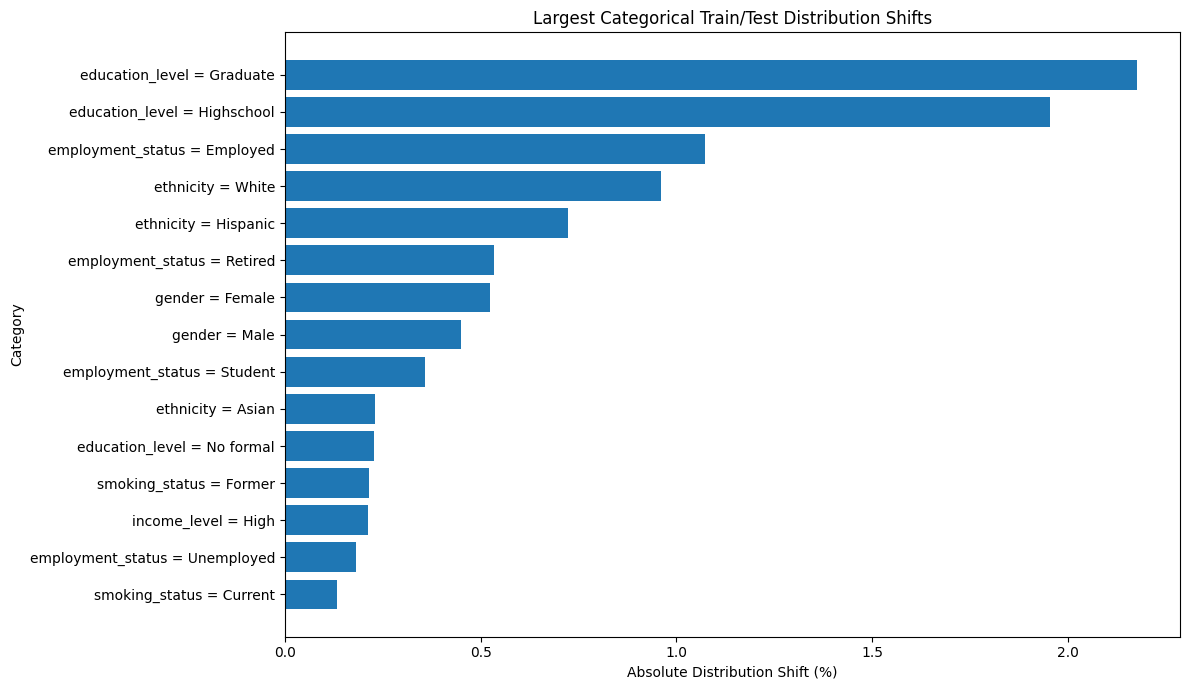

In [8]:

# ============================================================
#  CATEGORICAL TRAIN / TEST SHIFT
# ============================================================

categorical_shift_rows = []

for col in categorical_features:

    train_freq = train[col].value_counts(
        normalize=True
    )

    test_freq = test[col].value_counts(
        normalize=True
    )

    categories = sorted(
        set(train_freq.index) |
        set(test_freq.index)
    )

    for category in categories:

        train_pct = train_freq.get(
            category,
            0
        ) * 100

        test_pct = test_freq.get(
            category,
            0
        ) * 100

        categorical_shift_rows.append({
            "feature": col,
            "category": category,
            "train_%": train_pct,
            "test_%": test_pct,
            "absolute_shift_%": abs(
                train_pct - test_pct
            )
        })

categorical_shift_df = pd.DataFrame(
    categorical_shift_rows
)

print("=" * 75)
print(" CATEGORICAL TRAIN / TEST SHIFT")
print("=" * 75)

display(
    categorical_shift_df
    .sort_values(
        "absolute_shift_%",
        ascending=False
    )
    .round(3)
)

# ------------------------------------------------------------
# Largest category shifts
# ------------------------------------------------------------

largest_cat_shifts = (
    categorical_shift_df
    .sort_values(
        "absolute_shift_%",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12, 7))

labels = (
    largest_cat_shifts["feature"]
    + " = "
    + largest_cat_shifts["category"]
)

plt.barh(
    labels,
    largest_cat_shifts["absolute_shift_%"]
)

plt.xlabel("Absolute Distribution Shift (%)")
plt.ylabel("Category")
plt.title("Largest Categorical Train/Test Distribution Shifts")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 04. CATEGORICAL TARGET ANALYSIS

Now we investigate how strongly each categorical feature is associated
with `diagnosed_diabetes`.

For every category, we will calculate:

- Number of observations
- Diabetes-positive count
- Diabetes rate (%)
- Category frequency (%)

This is important because ROC-AUC depends on how well our model can
rank higher-risk and lower-risk observations.

We will examine:

1. Gender
2. Ethnicity
3. Education level
4. Income level
5. Smoking status
6. Employment status

We will also visualize the diabetes rate for every category.

In [9]:
# ============================================================
# CATEGORICAL TARGET RATE ANALYSIS
# ============================================================

categorical_cols = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "smoking_status",
    "employment_status"
]

print("=" * 75)
print(" CATEGORICAL TARGET RATE ANALYSIS")
print("=" * 75)

category_results = []

for col in categorical_cols:
    temp = (
        train.groupby(col)[TARGET]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )
    
    temp["feature"] = col
    temp["positive_rate_%"] = temp["mean"] * 100
    temp["frequency_%"] = temp["count"] / len(train) * 100
    
    category_results.append(
        temp[
            [
                "feature",
                col,
                "count",
                "sum",
                "frequency_%",
                "positive_rate_%"
            ]
        ].rename(columns={col: "category"})
    )

categorical_target_rates = pd.concat(
    category_results,
    ignore_index=True
)

categorical_target_rates = categorical_target_rates.sort_values(
    ["feature", "positive_rate_%"],
    ascending=[True, False]
)

display(categorical_target_rates.round(3))

 CATEGORICAL TARGET RATE ANALYSIS


,feature,category,count,sum,frequency_%,positive_rate_%
10,education_level,No formal,14945,9506.0,2.135,63.607
8,education_level,Graduate,261268,163817.0,37.324,62.701
9,education_level,Highschool,344145,213873.0,49.164,62.146
11,education_level,Postgraduate,79642,49111.0,11.377,61.665
20,employment_status,Employed,516170,322422.0,73.739,62.464
23,employment_status,Unemployed,49787,30974.0,7.112,62.213
22,employment_status,Student,18308,11380.0,2.615,62.159
21,employment_status,Retired,115735,71531.0,16.534,61.806
6,ethnicity,Other,17442,11092.0,2.492,63.594
3,ethnicity,Asian,60120,37785.0,8.589,62.849


### 04.1- Category Risk Range

The next view measures the spread between the highest and lowest
diabetes-positive rates inside each categorical feature.

A larger range means that the feature may provide stronger separation
between observations.

This is descriptive analysis only — the final model will determine
whether the feature adds predictive value.

In [10]:
# ============================================================
# TARGET-RATE RANGE BY CATEGORICAL FEATURE
# ============================================================

risk_range = (
    categorical_target_rates
    .groupby("feature")["positive_rate_%"]
    .agg(["min", "max"])
    .reset_index()
)

risk_range["range_%"] = risk_range["max"] - risk_range["min"]

risk_range = risk_range.sort_values(
    "range_%",
    ascending=False
)

print("=" * 75)
print(" TARGET RATE RANGE BY FEATURE")
print("=" * 75)

display(risk_range.round(3))

 TARGET RATE RANGE BY FEATURE


,feature,min,max,range_%
2,ethnicity,61.631,63.594,1.962
0,education_level,61.665,63.607,1.942
3,gender,62.221,64.057,1.836
4,income_level,62.029,63.033,1.004
1,employment_status,61.806,62.464,0.658
5,smoking_status,62.291,62.533,0.242


### 04.2- Visual Target Rates

Interactive-style visual inspection of category-level diabetes rates.

Higher bars indicate categories with higher observed diabetes-positive
rates in the training data.

These plots will help us identify potentially useful categorical
signals before model training.

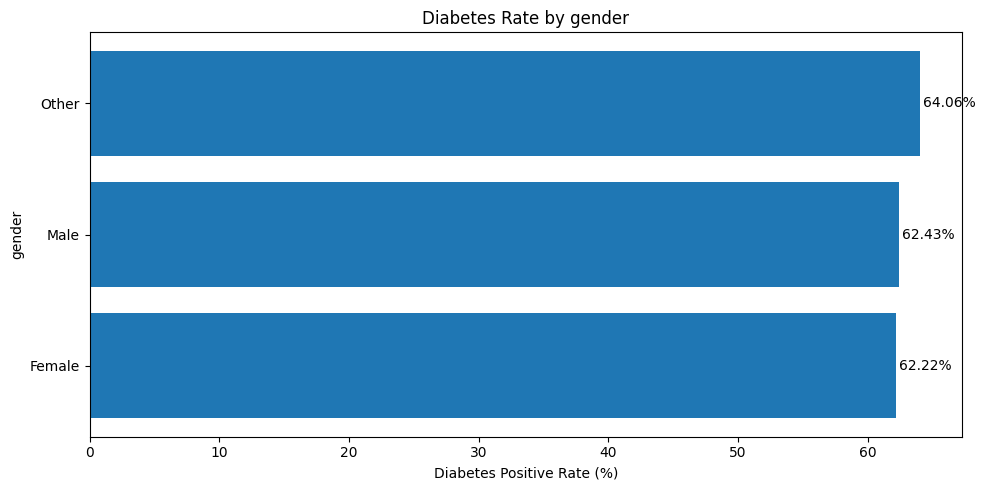

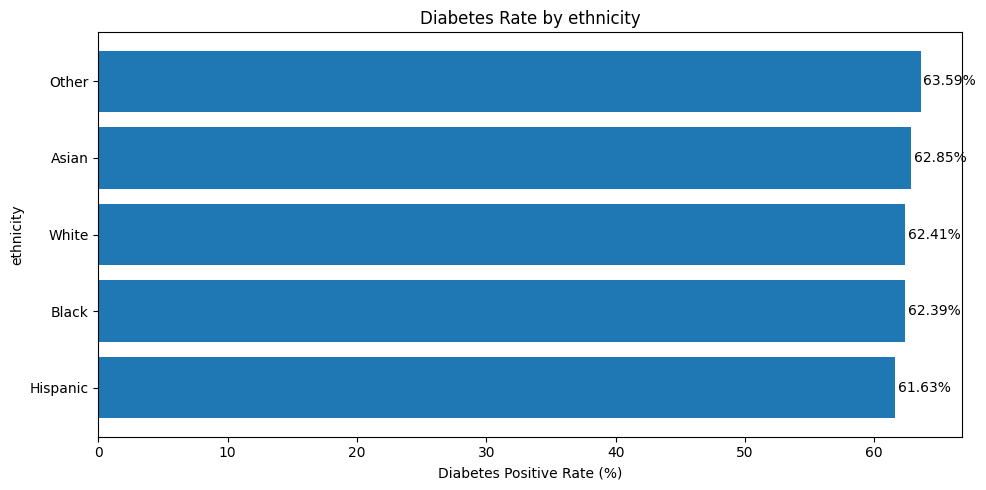

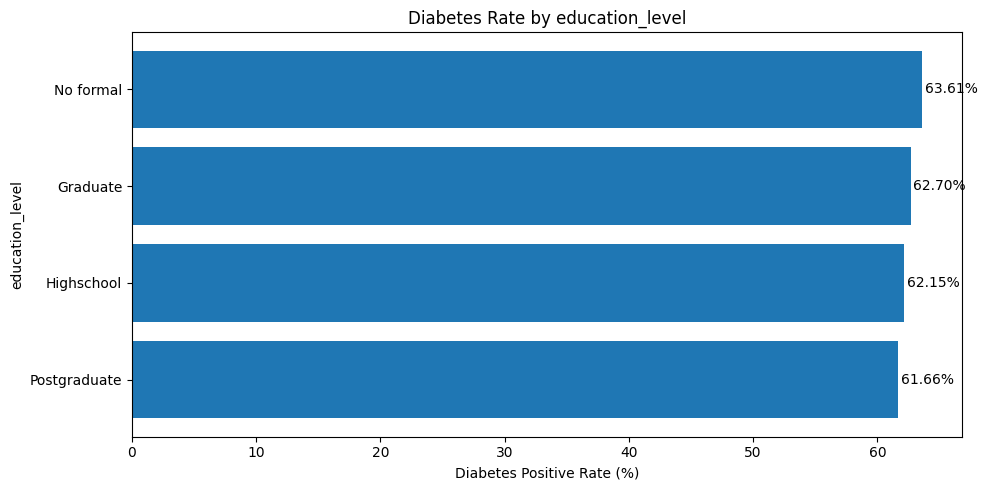

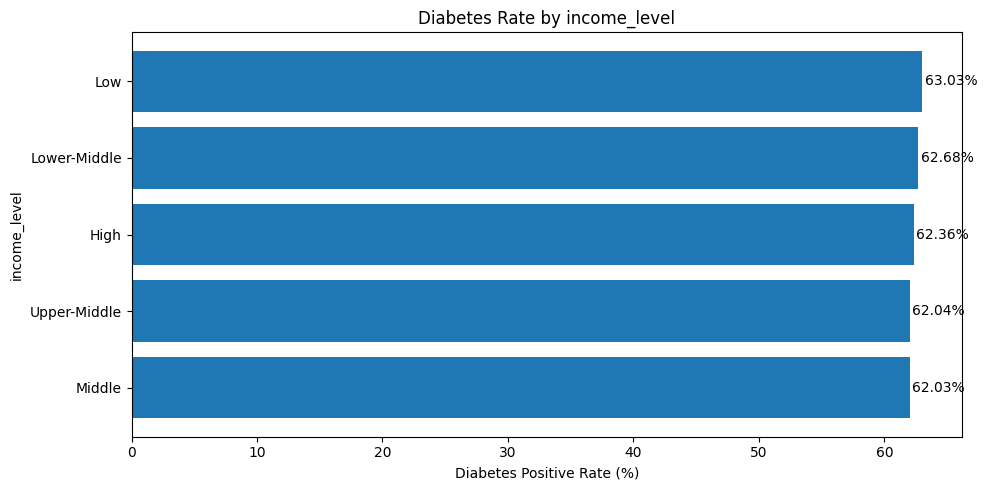

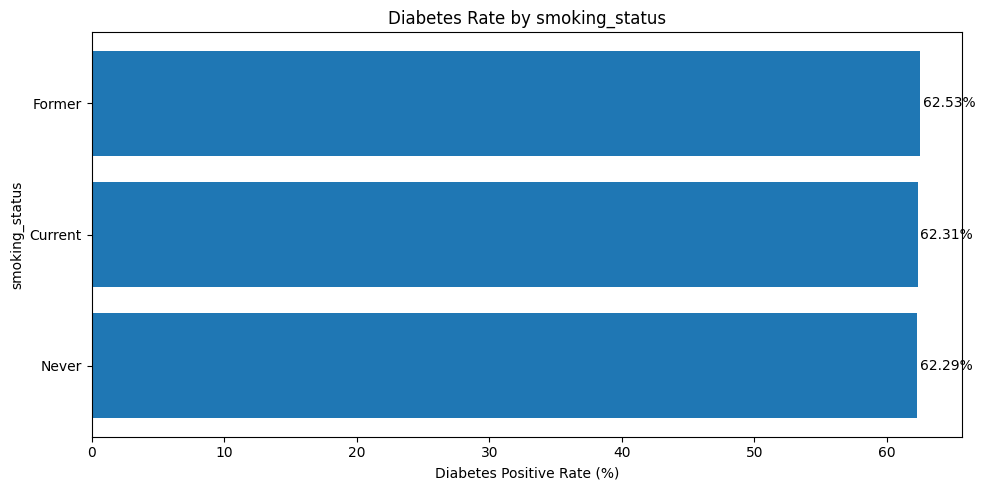

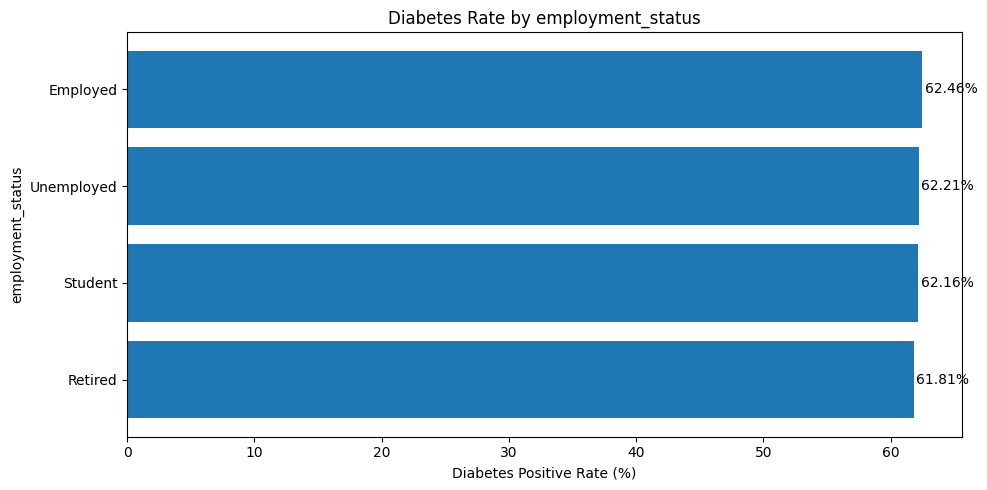

In [11]:
# ============================================================
# CATEGORY TARGET RATE PLOTS
# ============================================================

import matplotlib.pyplot as plt

for feature in categorical_cols:
    
    plot_df = (
        categorical_target_rates[
            categorical_target_rates["feature"] == feature
        ]
        .sort_values("positive_rate_%", ascending=True)
    )
    
    plt.figure(figsize=(10, 5))
    
    bars = plt.barh(
        plot_df["category"].astype(str),
        plot_df["positive_rate_%"]
    )
    
    plt.xlabel("Diabetes Positive Rate (%)")
    plt.ylabel(feature)
    plt.title(f"Diabetes Rate by {feature}")
    
    for bar, value in zip(bars, plot_df["positive_rate_%"]):
        plt.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}%",
            va="center"
        )
    
    plt.tight_layout()
    plt.show()

## 05. NUMERICAL FEATURE INTELLIGENCE

We now move from categorical variables to the numerical health and
lifestyle measurements.

The objective is to discover:

- Features with strong target separation
- Non-linear relationships
- Potential threshold effects
- Synthetic-data artifacts
- Features that may benefit from engineered ratios
- Features where simple correlation is misleading

Because the dataset contains 700,000 training rows, we will avoid
expensive pairwise operations on the entire dataset whenever sampling
provides an equivalent visualization.

In [12]:
# ============================================================
# NUMERICAL FEATURE TARGET SUMMARY
# ============================================================

numerical_cols = [
    col for col in train.select_dtypes(include=np.number).columns
    if col not in ["id", TARGET]
]

numeric_summary = []

for col in numerical_cols:
    positive = train.loc[train[TARGET] == 1, col]
    negative = train.loc[train[TARGET] == 0, col]
    
    numeric_summary.append({
        "feature": col,
        "mean_all": train[col].mean(),
        "mean_target_0": negative.mean(),
        "mean_target_1": positive.mean(),
        "mean_difference": positive.mean() - negative.mean(),
        "median_target_0": negative.median(),
        "median_target_1": positive.median(),
        "std": train[col].std()
    })

numeric_target_summary = pd.DataFrame(numeric_summary)

numeric_target_summary["abs_mean_difference"] = (
    numeric_target_summary["mean_difference"].abs()
)

numeric_target_summary = numeric_target_summary.sort_values(
    "abs_mean_difference",
    ascending=False
)

print("=" * 85)
print(" NUMERICAL TARGET SEPARATION")
print("=" * 85)

display(numeric_target_summary.round(4))

 NUMERICAL TARGET SEPARATION


,feature,mean_all,mean_target_0,mean_target_1,mean_difference,median_target_0,median_target_1,std,abs_mean_difference
2,physical_activity_minutes_per_week,80.2308,91.4119,73.4732,-17.9386,79.00,65.00,51.1951,17.9386
14,triglycerides,123.0818,120.1976,124.8250,4.6274,120.00,124.00,24.7394,4.6274
13,ldl_cholesterol,102.9059,100.3912,104.4257,4.0345,100.00,104.00,19.0224,4.0345
0,age,50.3597,47.9435,51.8201,3.8766,48.00,52.00,11.6555,3.8766
11,cholesterol_total,186.8188,184.9225,187.9649,3.0423,185.00,188.00,16.7308,3.0423
8,systolic_bp,116.2942,114.7769,117.2112,2.4343,115.00,117.00,11.0104,2.4343
12,hdl_cholesterol,53.8232,54.3892,53.4811,-0.9081,54.00,54.00,8.2665,0.9081
6,bmi,25.8747,25.4862,26.1095,0.6233,25.50,26.10,2.8607,0.6233
9,diastolic_bp,75.4409,75.1225,75.6334,0.5109,75.00,76.00,6.8258,0.5109
10,heart_rate,70.1677,69.9547,70.2965,0.3417,70.00,70.00,6.9387,0.3417


## 05.1- NUMERICAL TARGET SEPARATION

We now compare every numerical health/lifestyle feature between:

- `diagnosed_diabetes = 0`
- `diagnosed_diabetes = 1`

The key quantities are:

- Mean for each target class
- Median for each target class
- Absolute mean difference
- Relative difference

This helps identify variables with meaningful class separation.

Important:
A large mean difference does not automatically mean strong predictive
power. Non-linear relationships and interactions will be investigated
later.

In [13]:
# ============================================================
# NUMERICAL TARGET SEPARATION
# ============================================================

target_0 = train[train[TARGET] == 0]
target_1 = train[train[TARGET] == 1]

numeric_analysis = []

for col in numerical_cols:

    mean_0 = target_0[col].mean()
    mean_1 = target_1[col].mean()

    median_0 = target_0[col].median()
    median_1 = target_1[col].median()

    std_0 = target_0[col].std()
    std_1 = target_1[col].std()

    mean_diff = mean_1 - mean_0

    # Relative difference compared with class 0
    relative_diff = (
        mean_diff / abs(mean_0) * 100
        if mean_0 != 0 else np.nan
    )

    numeric_analysis.append({
        "feature": col,
        "mean_target_0": mean_0,
        "mean_target_1": mean_1,
        "mean_difference": mean_diff,
        "abs_mean_difference": abs(mean_diff),
        "relative_difference_%": relative_diff,
        "median_target_0": median_0,
        "median_target_1": median_1,
        "std_target_0": std_0,
        "std_target_1": std_1
    })

numeric_analysis = pd.DataFrame(numeric_analysis)

numeric_analysis = numeric_analysis.sort_values(
    "abs_mean_difference",
    ascending=False
)

print("=" * 100)
print(" NUMERICAL TARGET SEPARATION")
print("=" * 100)

display(numeric_analysis.round(4))

 NUMERICAL TARGET SEPARATION


,feature,mean_target_0,mean_target_1,mean_difference,abs_mean_difference,relative_difference_%,median_target_0,median_target_1,std_target_0,std_target_1
2,physical_activity_minutes_per_week,91.4119,73.4732,-17.9386,17.9386,-19.6240,79.00,65.00,60.3020,43.4286
14,triglycerides,120.1976,124.8250,4.6274,4.6274,3.8499,120.00,124.00,24.2776,24.8526
13,ldl_cholesterol,100.3912,104.4257,4.0345,4.0345,4.0188,100.00,104.00,18.8009,18.9943
0,age,47.9435,51.8201,3.8766,3.8766,8.0857,48.00,52.00,11.3528,11.5931
11,cholesterol_total,184.9225,187.9649,3.0423,3.0423,1.6452,185.00,188.00,16.5265,16.7494
8,systolic_bp,114.7769,117.2112,2.4343,2.4343,2.1209,115.00,117.00,10.8065,11.0311
12,hdl_cholesterol,54.3892,53.4811,-0.9081,0.9081,-1.6697,54.00,54.00,8.1621,8.3104
6,bmi,25.4862,26.1095,0.6233,0.6233,2.4457,25.50,26.10,2.8320,2.8524
9,diastolic_bp,75.1225,75.6334,0.5109,0.5109,0.6801,75.00,76.00,6.8218,6.8210
10,heart_rate,69.9547,70.2965,0.3417,0.3417,0.4885,70.00,70.00,6.9692,6.9170


## 05.2- Standardized Mean Difference

Raw differences are difficult to compare because every feature has a
different measurement scale.

We therefore calculate the standardized mean difference:

    SMD = (mean_target_1 - mean_target_0) / pooled_standard_deviation

This provides a scale-independent measure of class separation.

The result is descriptive and will be used to prioritize deeper
analysis, not as a standalone feature-selection rule.

In [14]:
# ============================================================
# STANDARDIZED MEAN DIFFERENCE
# ============================================================

smd_results = []

for col in numerical_cols:

    x0 = target_0[col]
    x1 = target_1[col]

    mean_0 = x0.mean()
    mean_1 = x1.mean()

    std_0 = x0.std()
    std_1 = x1.std()

    n0 = len(x0)
    n1 = len(x1)

    pooled_std = np.sqrt(
        (
            (n0 - 1) * std_0**2 +
            (n1 - 1) * std_1**2
        )
        / (n0 + n1 - 2)
    )

    smd = (
        (mean_1 - mean_0) / pooled_std
        if pooled_std != 0 else 0
    )

    smd_results.append({
        "feature": col,
        "SMD": smd,
        "absolute_SMD": abs(smd)
    })

smd_results = pd.DataFrame(smd_results)

smd_results = smd_results.sort_values(
    "absolute_SMD",
    ascending=False
)

print("=" * 80)
print(" STANDARDIZED MEAN DIFFERENCE")
print("=" * 80)

display(smd_results.round(4))

 STANDARDIZED MEAN DIFFERENCE


,feature,SMD,absolute_SMD
15,family_history_diabetes,0.4456,0.4456
2,physical_activity_minutes_per_week,-0.3556,0.3556
0,age,0.3370,0.3370
8,systolic_bp,0.2224,0.2224
6,bmi,0.2191,0.2191
13,ldl_cholesterol,0.2132,0.2132
14,triglycerides,0.1878,0.1878
11,cholesterol_total,0.1825,0.1825
7,waist_to_hip_ratio,0.1678,0.1678
12,hdl_cholesterol,-0.1100,0.1100


## 05.3- Correlation With Target

We now calculate Pearson correlation between numerical variables and
the binary diabetes target.

Because the target is binary, this is equivalent to a point-biserial
correlation.

Correlation is useful for identifying approximately linear signal,
but it can miss:

- Threshold effects
- Non-linear relationships
- U-shaped relationships
- Feature interactions

Therefore, correlation will NOT be our final feature-selection method.

In [15]:
# ============================================================
# TARGET CORRELATION
# ============================================================

correlation_results = []

for col in numerical_cols:

    corr = train[col].corr(train[TARGET])

    correlation_results.append({
        "feature": col,
        "correlation": corr,
        "absolute_correlation": abs(corr)
    })

correlation_results = pd.DataFrame(correlation_results)

correlation_results = correlation_results.sort_values(
    "absolute_correlation",
    ascending=False
)

print("=" * 80)
print(" NUMERICAL FEATURE CORRELATION WITH TARGET")
print("=" * 80)

display(correlation_results.round(5))

 NUMERICAL FEATURE CORRELATION WITH TARGET


,feature,correlation,absolute_correlation
15,family_history_diabetes,0.21106,0.21106
2,physical_activity_minutes_per_week,-0.16979,0.16979
0,age,0.16116,0.16116
8,systolic_bp,0.10713,0.10713
6,bmi,0.10558,0.10558
13,ldl_cholesterol,0.10277,0.10277
14,triglycerides,0.09064,0.09064
11,cholesterol_total,0.08811,0.08811
7,waist_to_hip_ratio,0.08105,0.08105
12,hdl_cholesterol,-0.05323,0.05323


## 05.4- Numerical Distribution Comparison

For the strongest numerical features, we compare their distributions
between the two target classes.

Since the training set contains 700,000 rows, we use a fixed random
sample for visualization.

The model will still train on the complete dataset later.

The objective is to detect:

- Separation
- Overlapping distributions
- Threshold behavior
- Skewness
- Multiple modes
- Synthetic-data artifacts

Top numerical features selected for distribution inspection:
['family_history_diabetes', 'physical_activity_minutes_per_week', 'age', 'systolic_bp', 'bmi', 'ldl_cholesterol', 'triglycerides', 'cholesterol_total']


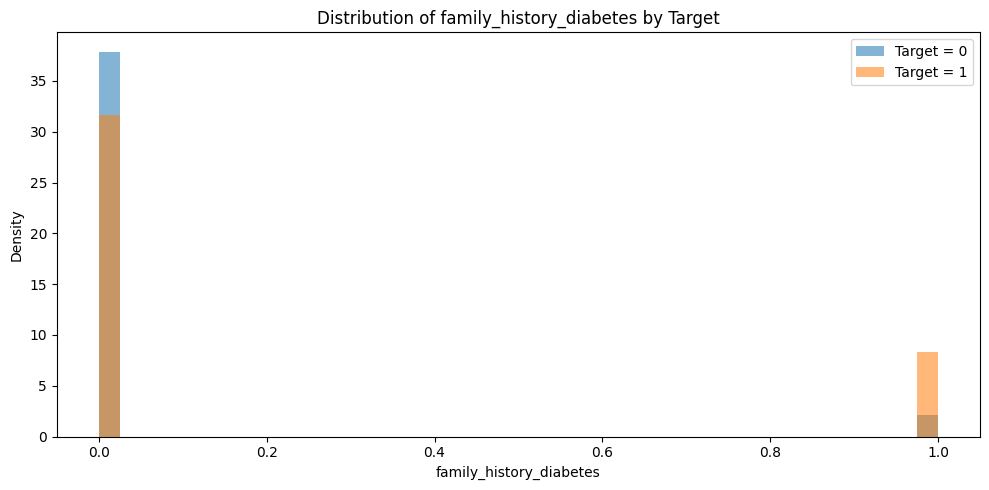

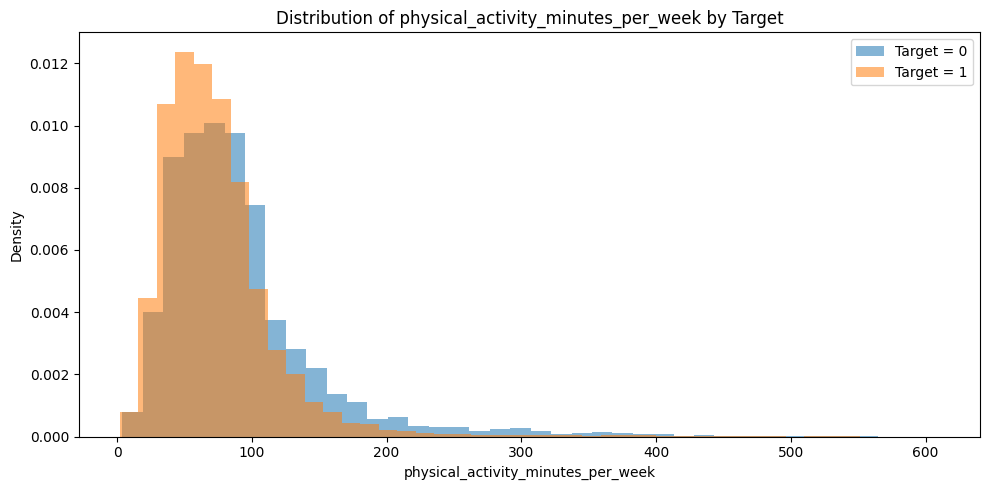

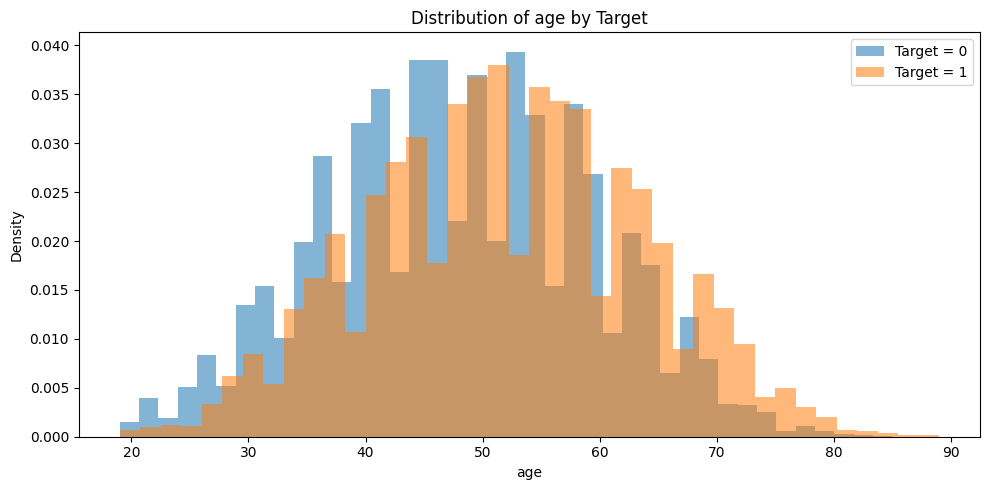

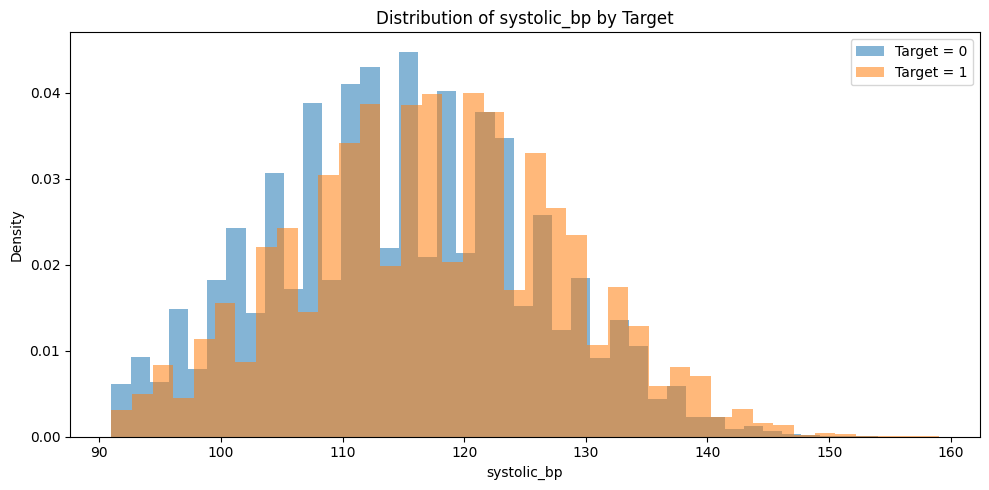

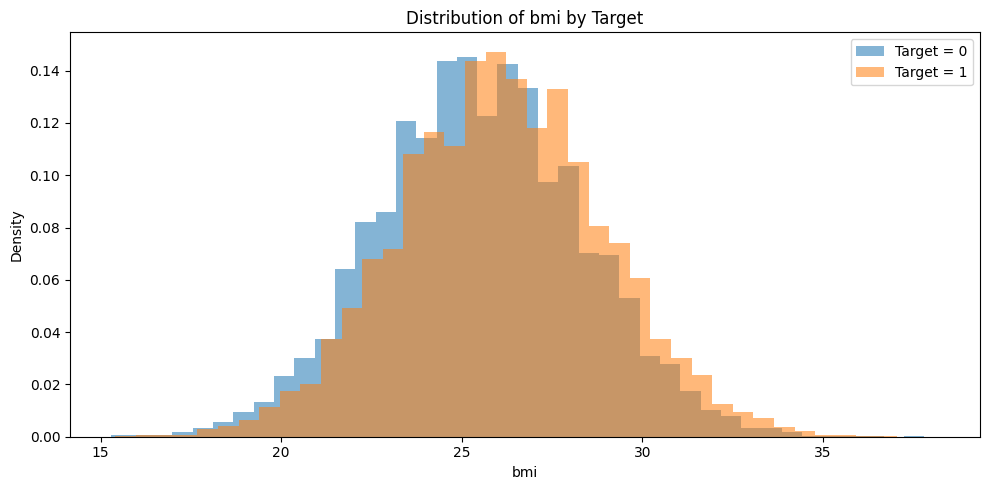

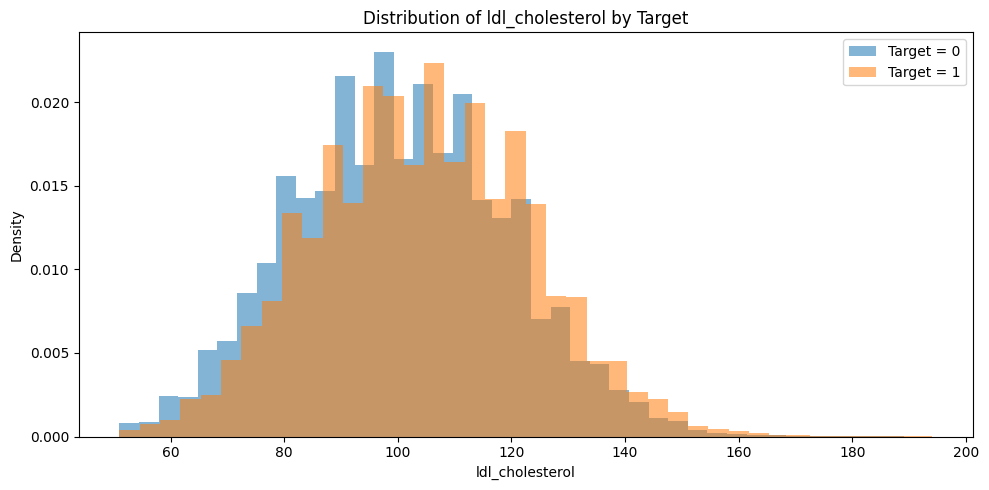

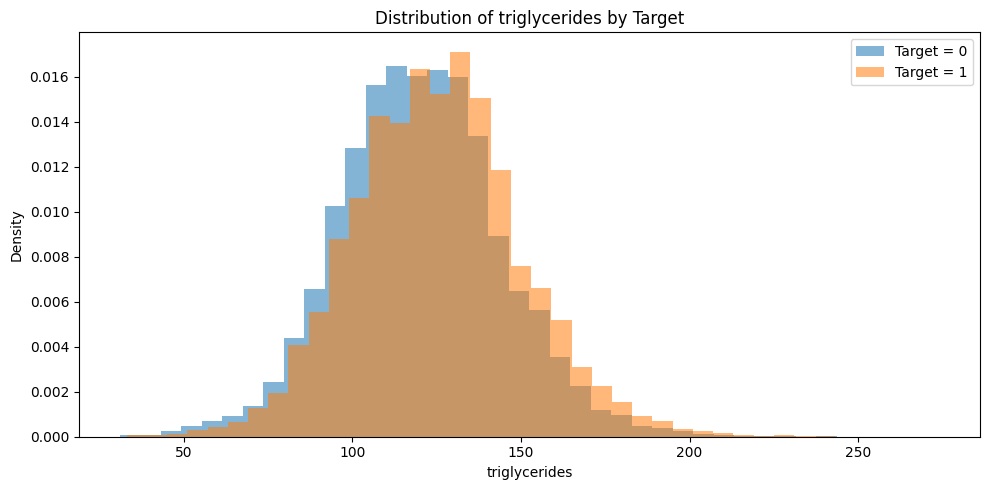

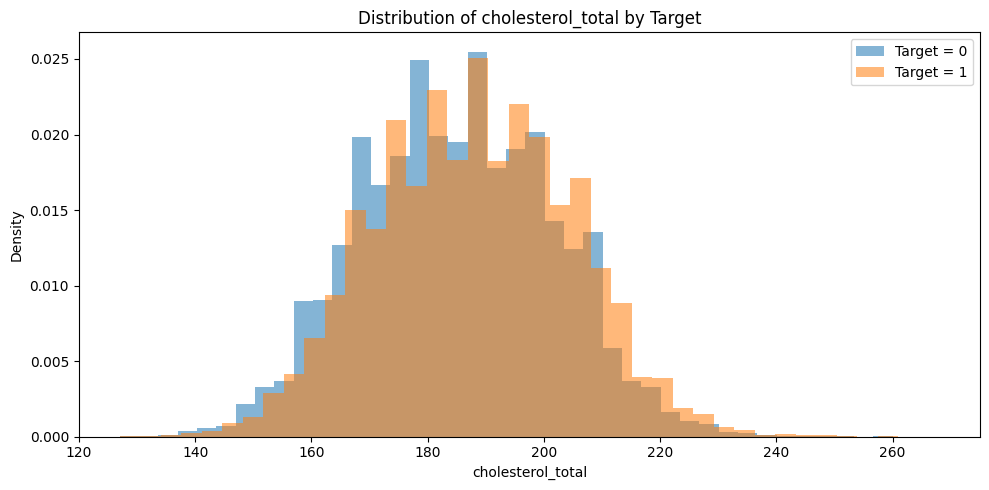

In [16]:
# ============================================================
# DISTRIBUTION COMPARISON
# ============================================================

# Select top numerical features based on absolute SMD
top_numeric_features = (
    smd_results
    .head(8)["feature"]
    .tolist()
)

print("Top numerical features selected for distribution inspection:")
print(top_numeric_features)

# Fixed-size sample for fast visualization
sample_size = min(100_000, len(train))

plot_sample = train.sample(
    n=sample_size,
    random_state=42
)

for feature in top_numeric_features:

    plt.figure(figsize=(10, 5))

    plt.hist(
        plot_sample.loc[
            plot_sample[TARGET] == 0,
            feature
        ],
        bins=40,
        alpha=0.55,
        density=True,
        label="Target = 0"
    )

    plt.hist(
        plot_sample.loc[
            plot_sample[TARGET] == 1,
            feature
        ],
        bins=40,
        alpha=0.55,
        density=True,
        label="Target = 1"
    )

    plt.title(f"Distribution of {feature} by Target")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 05.5- Binned Target Response

Correlation and mean differences can hide non-linear relationships.

Here we divide each important numerical feature into quantile bins
and calculate the diabetes-positive rate inside each bin.

This allows us to detect patterns such as:

- Increasing risk
- Decreasing risk
- Threshold effects
- Saturation
- U-shaped relationships
- Irregular synthetic patterns

These patterns are particularly useful for tree-based models.


 FEATURE: family_history_diabetes


,bin,count,positive_rate_%
0,0,70000,57.813
1,1,70000,58.081
2,2,70000,58.096
3,3,70000,58.124
4,4,70000,58.461
5,5,70000,57.804
6,6,70000,57.999
7,7,70000,58.081
8,8,70000,72.110
9,9,70000,86.726


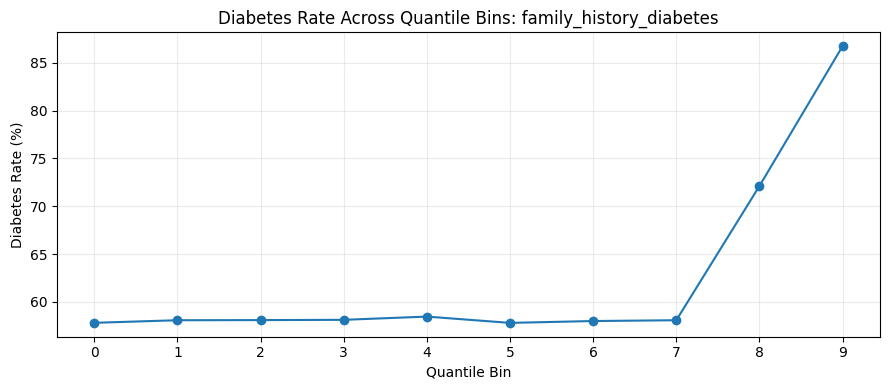


 FEATURE: physical_activity_minutes_per_week


,bin,count,positive_rate_%
0,0,70000,71.751
1,1,70000,68.804
2,2,70000,70.156
3,3,70000,66.437
4,4,70000,67.477
5,5,70000,62.991
6,6,70000,59.289
7,7,70000,59.796
8,8,70000,55.013
9,9,70000,41.581


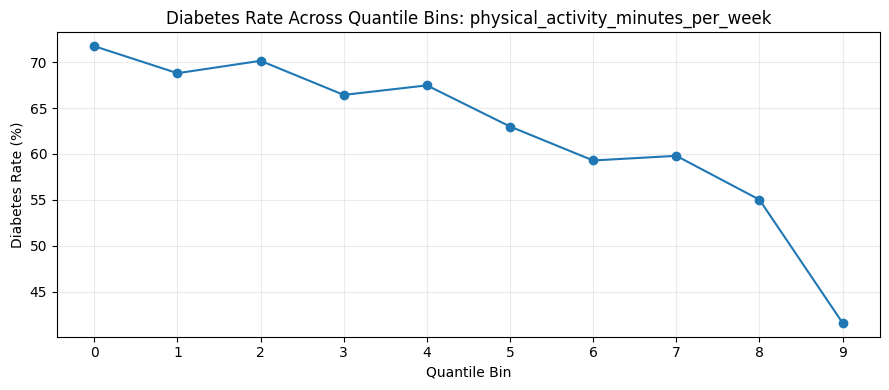


 FEATURE: age


,bin,count,positive_rate_%
0,0,70000,49.009
1,1,70000,54.626
2,2,70000,57.119
3,3,70000,59.851
4,4,70000,61.191
5,5,70000,62.923
6,6,70000,65.446
7,7,70000,66.150
8,8,70000,69.714
9,9,70000,77.267


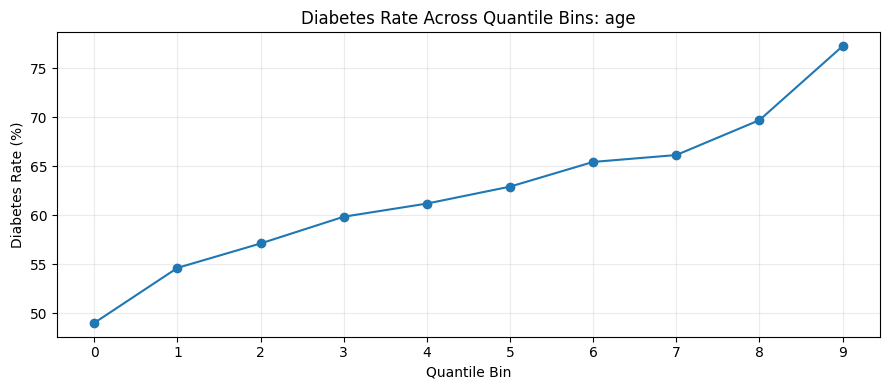


 FEATURE: systolic_bp


,bin,count,positive_rate_%
0,0,70000,53.524
1,1,70000,56.653
2,2,70000,58.960
3,3,70000,60.420
4,4,70000,61.691
5,5,70000,63.421
6,6,70000,64.080
7,7,70000,65.287
8,8,70000,67.799
9,9,70000,71.460


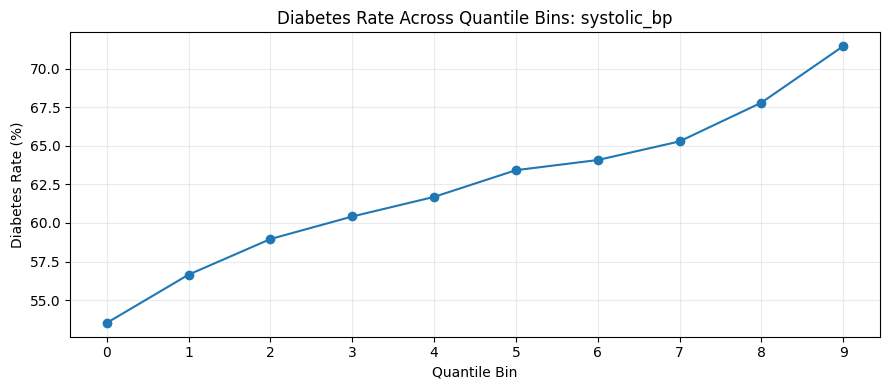


 FEATURE: bmi


,bin,count,positive_rate_%
0,0,70000,52.946
1,1,70000,56.943
2,2,70000,59.256
3,3,70000,60.789
4,4,70000,61.734
5,5,70000,62.397
6,6,70000,64.294
7,7,70000,66.334
8,8,70000,67.174
9,9,70000,71.429


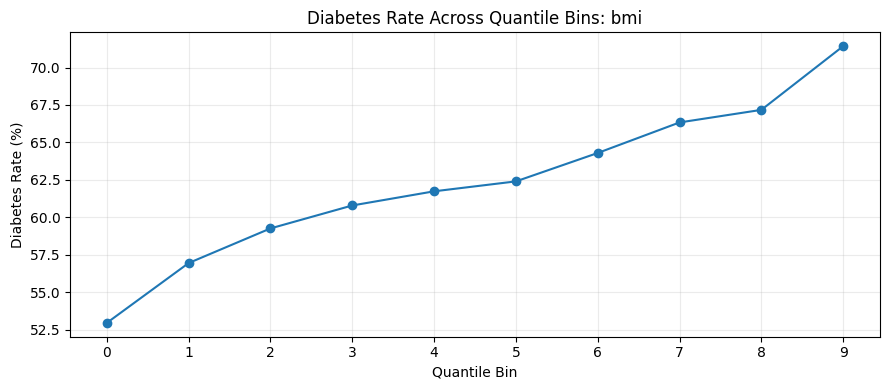


 FEATURE: ldl_cholesterol


,bin,count,positive_rate_%
0,0,70000,52.456
1,1,70000,58.339
2,2,70000,59.097
3,3,70000,60.706
4,4,70000,61.914
5,5,70000,63.837
6,6,70000,63.267
7,7,70000,64.649
8,8,70000,67.820
9,9,70000,71.211


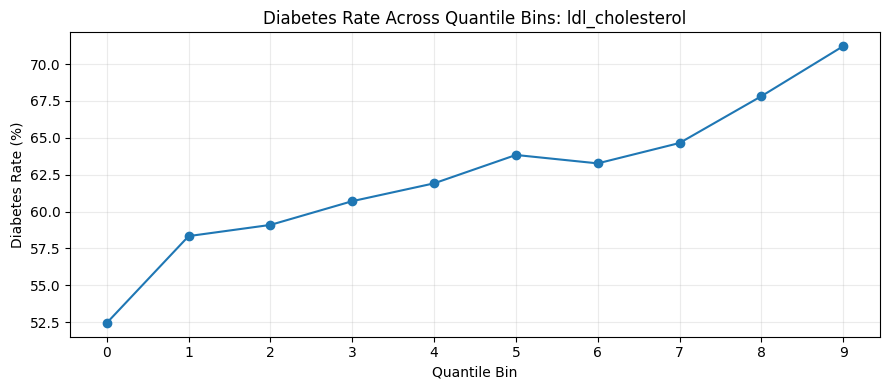


 FEATURE: triglycerides


,bin,count,positive_rate_%
0,0,70000,56.717
1,1,70000,54.531
2,2,70000,59.997
3,3,70000,61.821
4,4,70000,62.196
5,5,70000,60.704
6,6,70000,64.189
7,7,70000,65.343
8,8,70000,67.556
9,9,70000,70.241


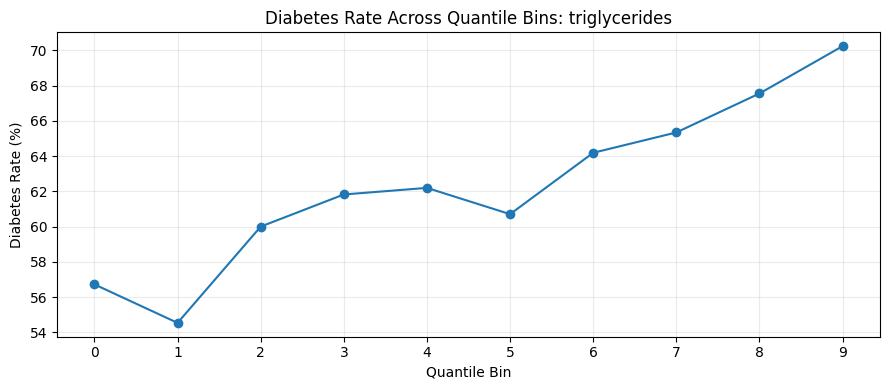


 FEATURE: cholesterol_total


,bin,count,positive_rate_%
0,0,70000,54.384
1,1,70000,58.700
2,2,70000,60.553
3,3,70000,60.731
4,4,70000,61.729
5,5,70000,62.390
6,6,70000,63.290
7,7,70000,63.653
8,8,70000,66.904
9,9,70000,70.961


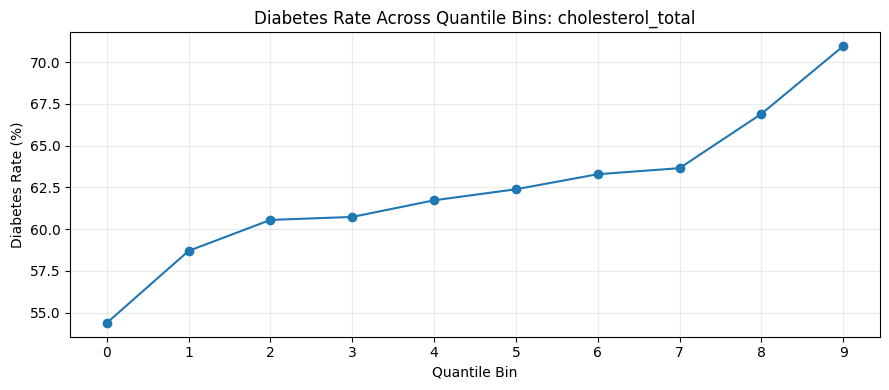


 FEATURE: waist_to_hip_ratio


,bin,count,positive_rate_%
0,0,70000,55.546
1,1,70000,57.289
2,2,70000,59.353
3,3,70000,60.546
4,4,70000,62.931
5,5,70000,64.029
6,6,70000,63.723
7,7,70000,65.146
8,8,70000,66.261
9,9,70000,68.473


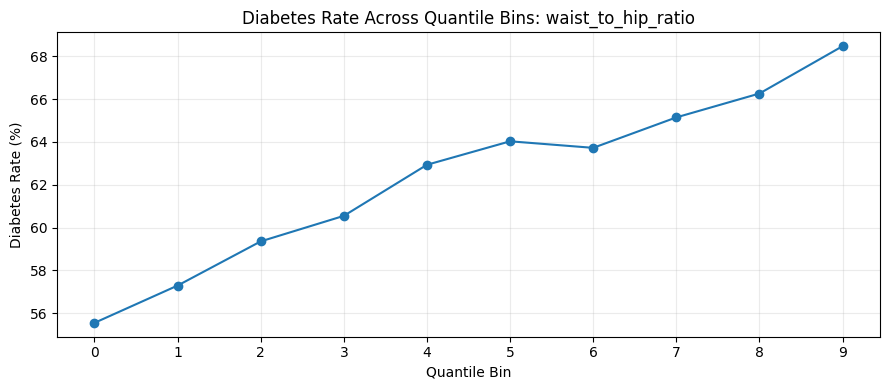


 FEATURE: hdl_cholesterol


,bin,count,positive_rate_%
0,0,70000,67.369
1,1,70000,65.484
2,2,70000,64.324
3,3,70000,63.054
4,4,70000,62.161
5,5,70000,61.221
6,6,70000,61.151
7,7,70000,59.849
8,8,70000,59.727
9,9,70000,58.954


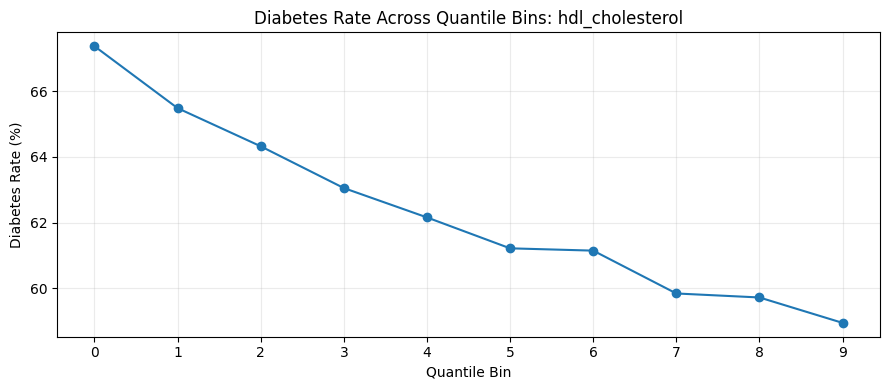

In [17]:
# ============================================================
# QUANTILE-BINNED TARGET RESPONSE
# ============================================================

# Use the strongest 10 numerical features
binned_features = (
    smd_results
    .head(10)["feature"]
    .tolist()
)

for feature in binned_features:

    temp = train[[feature, TARGET]].copy()

    # Rank first prevents qcut issues when many values are repeated
    ranks = temp[feature].rank(method="first")

    temp["bin"] = pd.qcut(
        ranks,
        q=10,
        labels=False
    )

    response = (
        temp.groupby("bin", observed=True)[TARGET]
        .agg(["count", "mean"])
        .reset_index()
    )

    response["positive_rate_%"] = response["mean"] * 100

    print("\n" + "=" * 80)
    print(f" FEATURE: {feature}")
    print("=" * 80)

    display(
        response[
            ["bin", "count", "positive_rate_%"]
        ].round(3)
    )

    plt.figure(figsize=(9, 4))

    plt.plot(
        response["bin"],
        response["positive_rate_%"],
        marker="o"
    )

    plt.title(f"Diabetes Rate Across Quantile Bins: {feature}")
    plt.xlabel("Quantile Bin")
    plt.ylabel("Diabetes Rate (%)")
    plt.xticks(range(10))
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 06 — HEALTH FEATURE ENGINEERING

The raw variables contain several measurements that can be transformed
into clinically meaningful mathematical relationships.

We will create lightweight features such as:

- Pulse pressure
- Mean arterial pressure
- Total cholesterol / HDL ratio
- LDL / HDL ratio
- Triglycerides / HDL ratio
- BMI × age interaction
- Waist-to-hip × BMI interaction
- Sleep / screen-time balance
- Activity / age relationship

These features are inexpensive to calculate and are especially useful
for linear models and gradient-boosting models.

We will keep the original variables as well.

In [18]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

def add_engineered_features(df):
    df = df.copy()

    # --------------------------------------------------------
    # Blood pressure
    # --------------------------------------------------------
    df["pulse_pressure"] = (
        df["systolic_bp"] - df["diastolic_bp"]
    )

    df["mean_arterial_pressure"] = (
        df["systolic_bp"] + 2 * df["diastolic_bp"]
    ) / 3

    # --------------------------------------------------------
    # Cholesterol ratios
    # --------------------------------------------------------
    df["total_hdl_ratio"] = (
        df["cholesterol_total"] /
        (df["hdl_cholesterol"] + 1e-6)
    )

    df["ldl_hdl_ratio"] = (
        df["ldl_cholesterol"] /
        (df["hdl_cholesterol"] + 1e-6)
    )

    df["triglyceride_hdl_ratio"] = (
        df["triglycerides"] /
        (df["hdl_cholesterol"] + 1e-6)
    )

    # --------------------------------------------------------
    # Lifestyle balance
    # --------------------------------------------------------
    df["sleep_screen_balance"] = (
        df["sleep_hours_per_day"] -
        df["screen_time_hours_per_day"]
    )

    df["activity_per_age"] = (
        df["physical_activity_minutes_per_week"] /
        (df["age"] + 1)
    )

    # --------------------------------------------------------
    # Body composition interactions
    # --------------------------------------------------------
    df["bmi_age_interaction"] = (
        df["bmi"] * df["age"]
    )

    df["bmi_waist_interaction"] = (
        df["bmi"] * df["waist_to_hip_ratio"]
    )

    # --------------------------------------------------------
    # Cardiometabolic interactions
    # --------------------------------------------------------
    df["age_bmi_bp"] = (
        df["age"] *
        df["bmi"] *
        df["systolic_bp"]
    )

    df["cholesterol_triglyceride_ratio"] = (
        df["cholesterol_total"] /
        (df["triglycerides"] + 1e-6)
    )

    return df


train_fe = add_engineered_features(train)
test_fe = add_engineered_features(test)

print("=" * 80)
print(" FEATURE ENGINEERING COMPLETE")
print("=" * 80)

print("Original train shape :", train.shape)
print("Engineered train shape:", train_fe.shape)

print("\nNew features:")
new_features = [
    col for col in train_fe.columns
    if col not in train.columns
]

for feature in new_features:
    print(" -", feature)

 FEATURE ENGINEERING COMPLETE
Original train shape : (700000, 26)
Engineered train shape: (700000, 37)

New features:
 - pulse_pressure
 - mean_arterial_pressure
 - total_hdl_ratio
 - ldl_hdl_ratio
 - triglyceride_hdl_ratio
 - sleep_screen_balance
 - activity_per_age
 - bmi_age_interaction
 - bmi_waist_interaction
 - age_bmi_bp
 - cholesterol_triglyceride_ratio
